<a href="https://colab.research.google.com/github/mochaheree/cohort-retention-churn-analytics/blob/main/notebook/SaaS_Subscription_%26_Churn_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [ ]:
acc = pd.read_csv("/content/drive/MyDrive/Dataset/saas-subs/ravenstack_accounts.csv")
ce = pd.read_csv("/content/drive/MyDrive/Dataset/saas-subs/ravenstack_churn_events.csv")
fu = pd.read_csv("/content/drive/MyDrive/Dataset/saas-subs/ravenstack_feature_usage.csv")
subs = pd.read_csv("/content/drive/MyDrive/Dataset/saas-subs/ravenstack_subscriptions.csv")
st = pd.read_csv("/content/drive/MyDrive/Dataset/saas-subs/ravenstack_support_tickets.csv")

In [ ]:
subs.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,end_date_eff,start_month,end_month
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,2024-04-12,2023-12,2024-04
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,2024-12-31,2024-06,2024-12
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False,2024-12-31,2024-11,2024-12
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,2024-12-13,2024-11,2024-12
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,2024-12-31,2024-01,2024-12


# Cohort Retention Table

In [ ]:
def build_retention(subs_df: pd.DataFrame, max_month: int = 12):
    df = subs_df.copy()

    df["start_date"] = pd.to_datetime(df["start_date"])
    df["end_date"] = pd.to_datetime(df["end_date"])

    obs_end = df["start_date"].max()
    df["end_date_eff"] = df["end_date"].fillna(obs_end)
    df["start_month"] = df["start_date"].dt.to_period("M")
    df["end_month"] = df["end_date_eff"].dt.to_period("M")
    n_months = (df["end_month"] - df["start_month"]).apply(lambda x: x.n) + 1

    expanded = df.loc[df.index.repeat(n_months)].copy()
    expanded["active_month"] = expanded.groupby(level=0).cumcount()
    expanded["cohort_month"] = expanded["start_month"].dt.to_timestamp()
    expanded["activity_month"] = (expanded["start_month"] + expanded["active_month"]).dt.to_timestamp()

    cohort_counts = (
        expanded
        .groupby(["cohort_month", "active_month"])["account_id"]
        .nunique()
        .reset_index(name="n_customers")
    )

    cohort_pivot = cohort_counts.pivot(
        index="cohort_month",
        columns="active_month",
        values="n_customers"
    )

    cohort_size = cohort_pivot[0]
    retention = cohort_pivot.divide(cohort_size, axis=0)
    retention_trunc = retention.loc[:, 0:max_month]

    return retention_trunc, cohort_pivot, expanded

In [ ]:
MAX_MONTH = 12

subs_monthly = subs[subs["billing_frequency"] == "monthly"]
subs_annual  = subs[subs["billing_frequency"] == "annual"]

ret_all, pivot_all, _ = build_retention(subs, max_month=12)
ret_m, pivot_m, exp_m = build_retention(subs_monthly, max_month=MAX_MONTH)
ret_a, pivot_a, exp_a = build_retention(subs_annual,  max_month=MAX_MONTH)

print("Annual + Monthly cohorts", ret_all.shape)
print("Monthly cohorts:", ret_m.shape)
print("Annual cohorts :", ret_a.shape)

comparison = pd.DataFrame({
    "All": ret_all.mean(),
    "Monthly": ret_m.mean(),
    "Annual": ret_a.mean()
})

print(comparison.iloc[:6])

Annual + Monthly cohorts (24, 13)
Monthly cohorts: (24, 13)
Annual cohorts : (24, 13)
                   All   Monthly    Annual
active_month                              
0             1.000000  1.000000  1.000000
1             0.997838  0.998021  0.995716
2             0.992574  0.990244  0.991737
3             0.986135  0.986016  0.982560
4             0.977877  0.979188  0.975149
5             0.971324  0.968672  0.965778


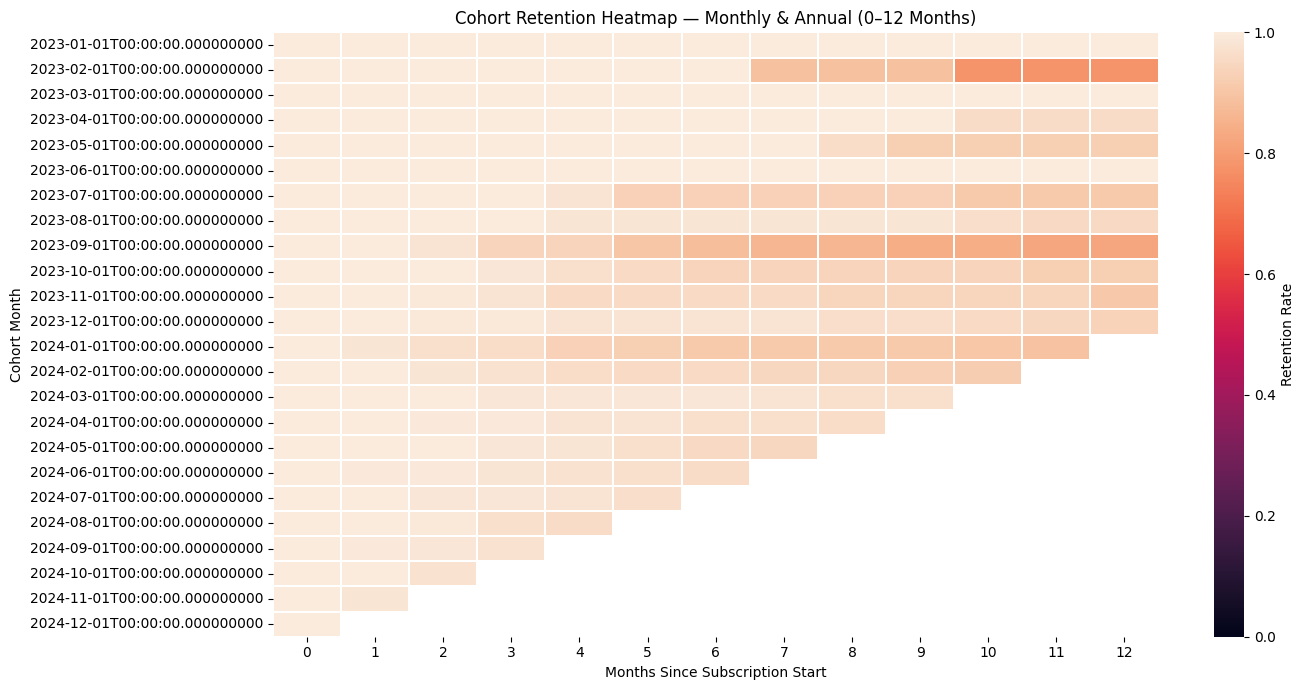

In [ ]:

plt.figure(figsize=(14, 7))
mask_all = ret_all.isna()

sns.heatmap(
    ret_all,
    mask=mask_all,
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Retention Rate"}
)

plt.title("Cohort Retention Heatmap — Monthly & Annual (0–12 Months)")
plt.xlabel("Months Since Subscription Start")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

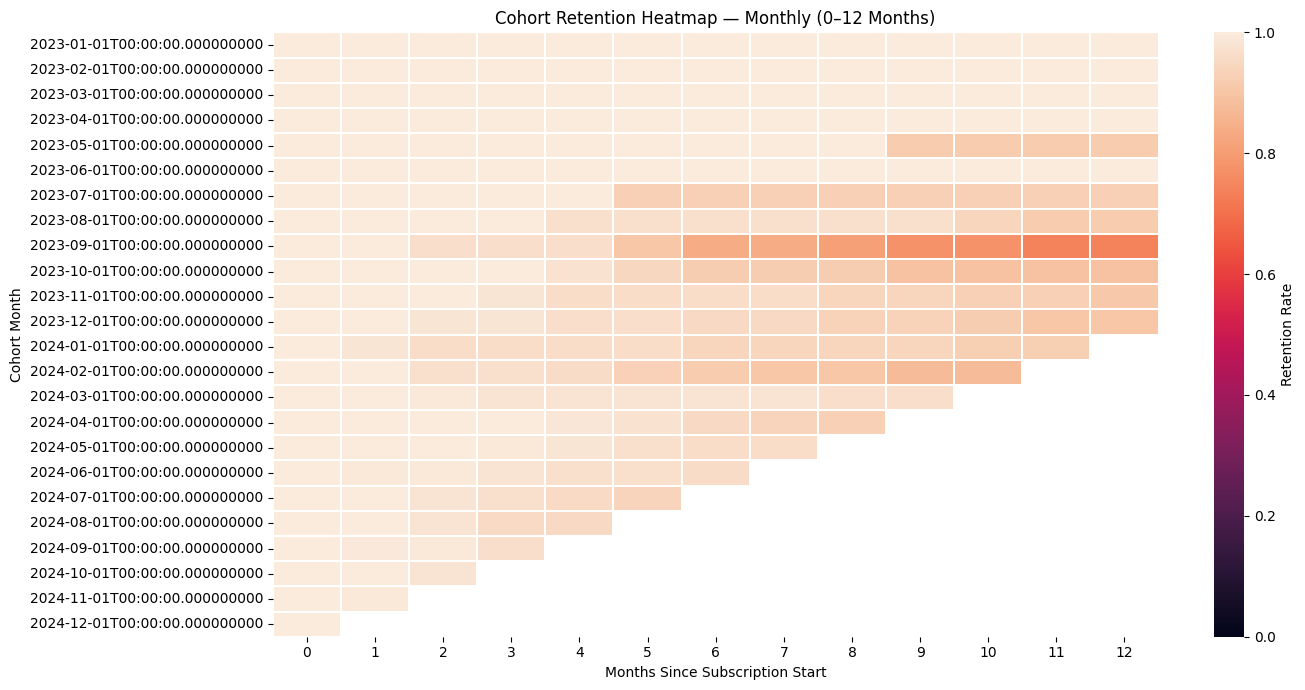

In [ ]:

plt.figure(figsize=(14, 7))
mask_m = ret_m.isna()

sns.heatmap(
    ret_m,
    mask=mask_m,
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Retention Rate"}
)

plt.title("Cohort Retention Heatmap — Monthly (0–12 Months)")
plt.xlabel("Months Since Subscription Start")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

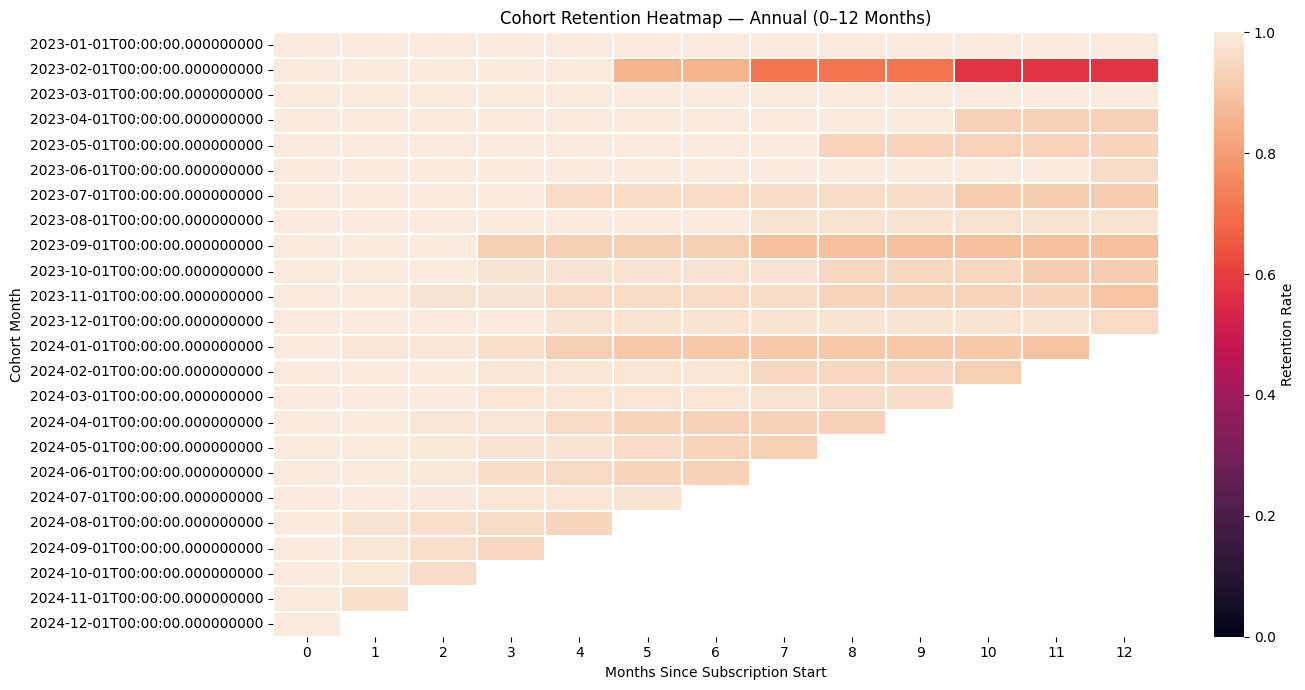

In [ ]:

plt.figure(figsize=(14, 7))
mask_a = ret_a.isna()

sns.heatmap(
    ret_a,
    mask=mask_a,
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Retention Rate"}
)

plt.title("Cohort Retention Heatmap — Annual (0–12 Months)")
plt.xlabel("Months Since Subscription Start")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

# Revenue Retention Table

In [ ]:
def build_revenue_retention(subs_df, max_month=12):
    subs_df = subs_df.copy()

    subs_df["start_date"] = pd.to_datetime(subs_df["start_date"])
    subs_df["end_date"] = pd.to_datetime(subs_df["end_date"])

    obs_end = subs_df["start_date"].max()
    subs_df["end_date_eff"] = subs_df["end_date"].fillna(obs_end)

    subs_df["start_month"] = subs_df["start_date"].dt.to_period("M")
    subs_df["end_month"] = subs_df["end_date_eff"].dt.to_period("M")

    n_months = (subs_df["end_month"] - subs_df["start_month"]).apply(lambda x: x.n) + 1
    expanded = subs_df.loc[subs_df.index.repeat(n_months)].copy()
    expanded["active_month"] = expanded.groupby(level=0).cumcount()
    expanded["cohort_month"] = expanded["start_month"].dt.to_timestamp()

    revenue_counts = (
        expanded.groupby(["cohort_month", "active_month"])["mrr_amount"]
        .sum()
        .reset_index()
    )

    revenue_pivot = revenue_counts.pivot(
        index="cohort_month",
        columns="active_month",
        values="mrr_amount"
    )

    revenue_retention = revenue_pivot.divide(revenue_pivot[0], axis=0)

    return revenue_retention.loc[:, 0:max_month]

In [ ]:

rev_all = build_revenue_retention(subs, max_month=MAX_MONTH)
rev_m   = build_revenue_retention(subs[subs["billing_frequency"]=="monthly"], max_month=MAX_MONTH)
rev_a   = build_revenue_retention(subs[subs["billing_frequency"]=="annual"], max_month=MAX_MONTH)

comparison_rev = pd.DataFrame({
    "All": rev_all.mean(),
    "Monthly": rev_m.mean(),
    "Annual": rev_a.mean()
})

comparison_rev

,All,Monthly,Annual
active_month,,,
0,1.000000,1.000000,1.000000
1,0.995506,0.996463,0.994960
2,0.988596,0.985753,0.991529
3,0.978618,0.981815,0.977703
4,0.971664,0.972620,0.973331
5,0.961518,0.968914,0.959817
6,0.954594,0.956134,0.957940
7,0.945220,0.949784,0.945996
8,0.926325,0.938793,0.922503


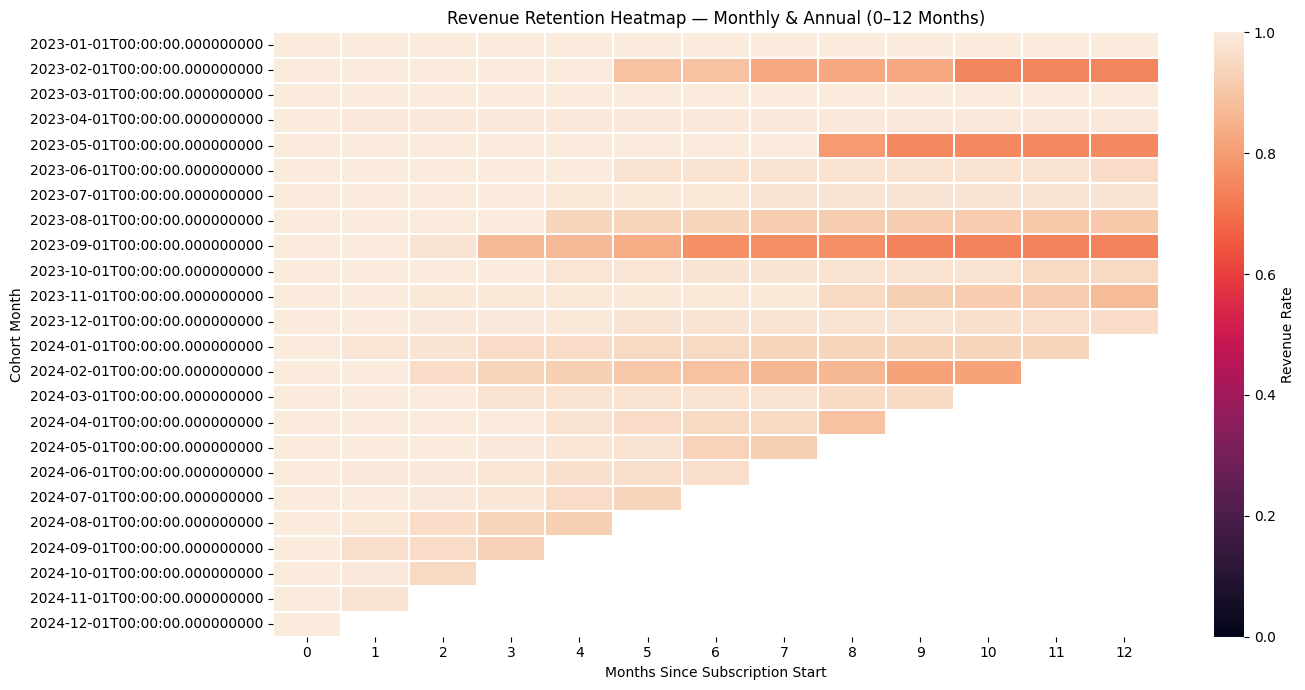

In [ ]:

plt.figure(figsize=(14, 7))
mask_all = rev_all.isna()

sns.heatmap(
    rev_all,
    mask=mask_all,
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Revenue Rate"}
)

plt.title("Revenue Retention Heatmap — Monthly & Annual (0–12 Months)")
plt.xlabel("Months Since Subscription Start")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

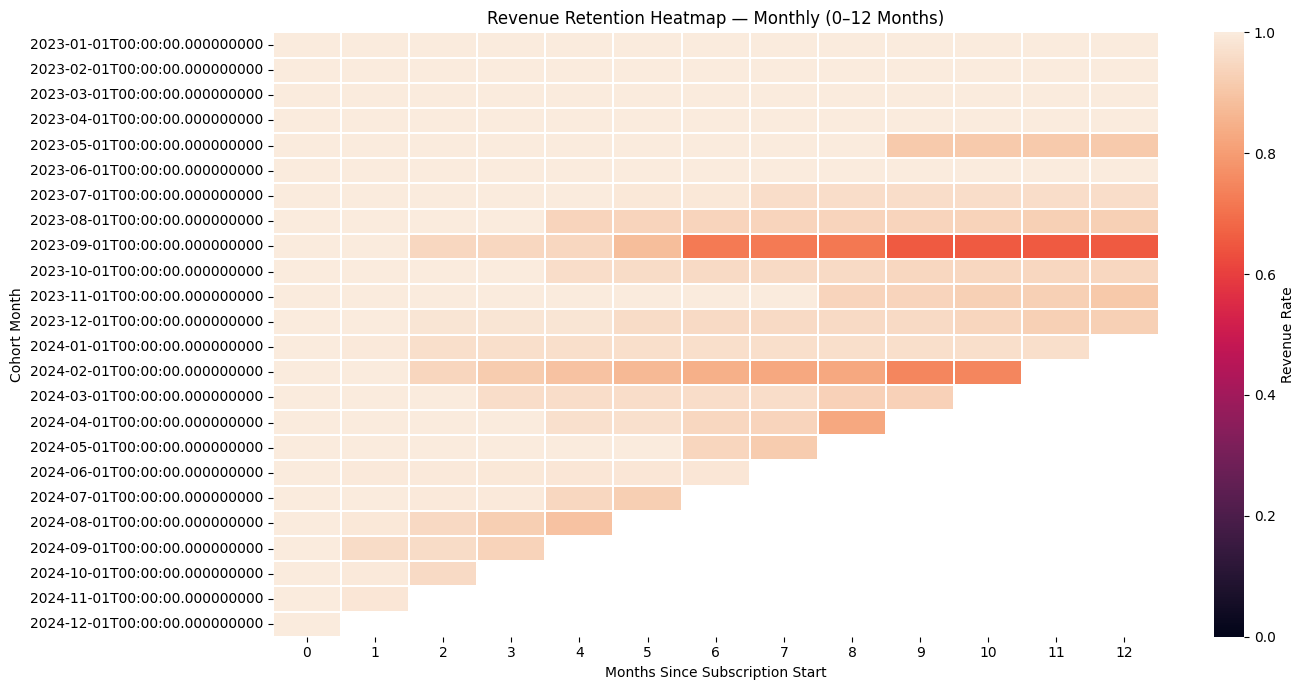

In [ ]:

plt.figure(figsize=(14, 7))
mask_m = rev_m.isna()

sns.heatmap(
    rev_m,
    mask=mask_m,
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Revenue Rate"}
)

plt.title("Revenue Retention Heatmap — Monthly (0–12 Months)")
plt.xlabel("Months Since Subscription Start")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

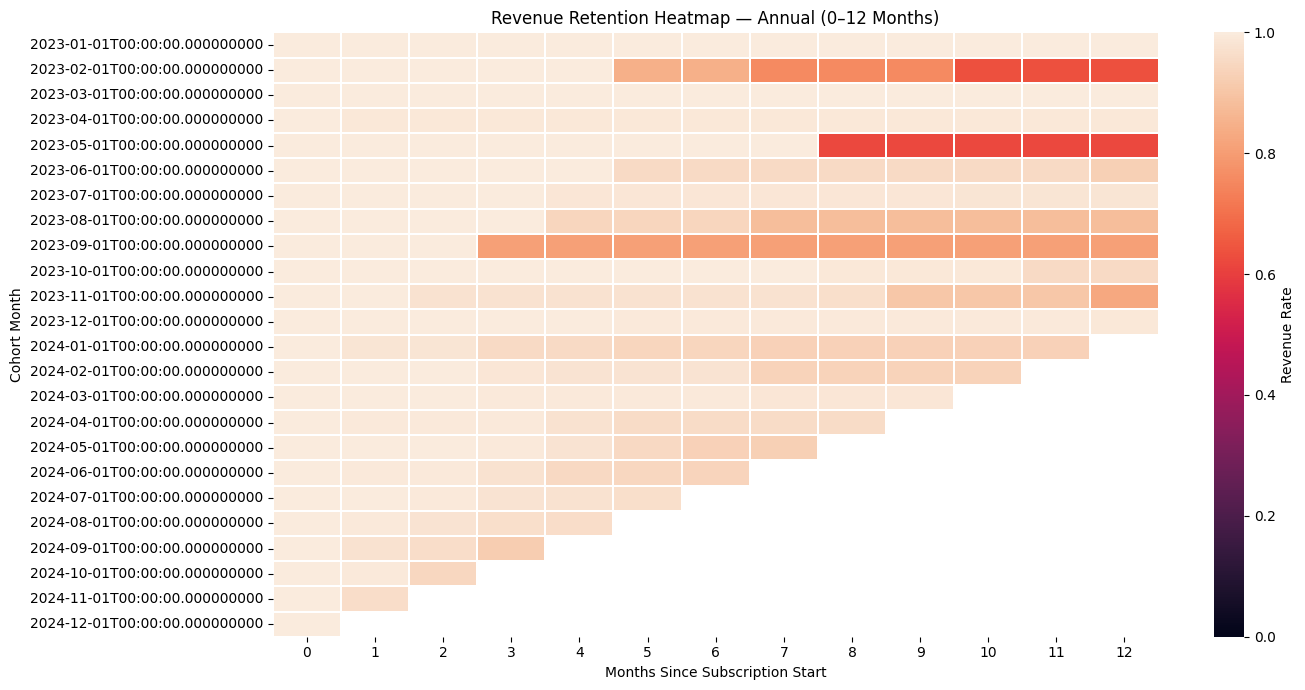

In [ ]:

plt.figure(figsize=(14, 7))
mask_a = rev_a.isna()

sns.heatmap(
    rev_a,
    mask=mask_a,
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Revenue Rate"}
)

plt.title("Revenue Retention Heatmap — Annual (0–12 Months)")
plt.xlabel("Months Since Subscription Start")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

# Retention by Plan Tier

In [ ]:
plan_summary = subs.groupby("plan_tier").agg(
    customers=("account_id", "nunique"),
    churn_rate=("churn_flag", "mean"),
    upgrade_rate=("upgrade_flag", "mean"),
    downgrade_rate=("downgrade_flag", "mean"),
    avg_mrr=("mrr_amount", "mean")
)

plan_summary

,customers,churn_rate,upgrade_rate,downgrade_rate,avg_mrr
plan_tier,,,,,
Basic,480,0.094881,0.088015,0.037453,474.679775
Enterprise,479,0.099826,0.112594,0.039466,4917.713871
Pro,474,0.096716,0.115821,0.053731,1256.769552


In [ ]:
ret_all_trunc = ret_all.iloc[:, :12]

retention_long = (
    ret_all_trunc
    .reset_index()
    .melt(id_vars="cohort_month",
          var_name="month_index",
          value_name="retention_rate")
)

revenue_long = (
    rev_all_trunc
    .reset_index()
    .melt(id_vars="cohort_month",
          var_name="month_index",
          value_name="revenue_retention_rate")
)

kpi_summary = pd.DataFrame({
    "month_1_retention": [ret_all.mean()[1]],
    "month_6_retention": [ret_all.mean()[6]],
    "month_12_retention": [ret_all.mean()[12]],
    "month_6_revenue_retention": [rev_all.mean()[6]],
    "overall_churn_rate": [subs["churn_flag"].mean()]
})


retention_long.to_csv("cohort_retention_long.csv", index=False)
revenue_long.to_csv("revenue_retention_long.csv", index=False)
kpi_summary.to_csv("kpi_summary.csv", index=False)
plan_summary.to_csv("plan_summary.csv")